## Full Evaluation Suite
Loads all result tables. Run `python -m src.complete_blueprint_steps` first if any file is missing.

In [1]:
import os
os.chdir(r'D:\424_project-main')  # ensure relative paths resolve from project root


In [2]:
import pandas as pd
from pathlib import Path

# Ablation table: models B0-B4, P1-P3 with majority-class and mean-profile baselines
p = Path('results/ablation_table.csv')
ablation = pd.read_csv(p) if p.exists() else None
print('Model comparison table:')
print(ablation if ablation is not None else 'MISSING - run python -m src.complete_blueprint_steps')


Model comparison table:
  model  test_top1  test_top3  test_top5  test_top13     apl_db  \
0    B1   0.009555   0.041980   0.153039    0.392544  14.166042   
1    B3   0.120927   0.284148   0.310464    0.351660   7.287043   
2    P1   0.055921   0.158208   0.416353    0.629386  12.333862   
3    P3   0.126566   0.323935   0.467888    0.632206  10.174790   
4    B0   0.006736   0.007989   0.008772    0.010338  11.073256   

   profile_mae_db  profile_rank_corr  majority_baseline_top1  \
0       34.632954          -0.008127                0.204104   
1       36.960510           0.071598                0.204104   
2       35.991352           0.073845                0.204104   
3        2.486694           0.237422                0.204104   
4       13.135901           0.000854                0.204104   

   mean_profile_mae_db  
0             3.106604  
1             3.106604  
2             3.106604  
3             3.106604  
4             3.106604  


In [3]:
# Telecom utility table: probes-per-decision, search reduction, APL
p = Path('results/telecom_utility_table.csv')
telecom = pd.read_csv(p) if p.exists() else None
print('Telecom utility table:')
print(telecom if telecom is not None else 'MISSING')


Telecom utility table:
             method  miss_rate  avg_probes  search_reduction    apl_db  \
0  static_power_crc   0.045739   32.373745          0.873540  0.631688   
1        online_aci   0.074718   17.108240          0.933171  1.075456   
2     conformal_pid   0.085683   48.708019          0.809734  1.278293   
3   exact_label_crc   0.043703  168.349311          0.342386       NaN   

   outage_p_gap_gt_3db  eta_from_val_only  q_max_calib_p99  exact_coverage  
0             0.045739                NaN              NaN             NaN  
1             0.074718                0.1        35.525387             NaN  
2             0.085683                NaN              NaN             NaN  
3                  NaN                NaN              NaN        0.956297  


In [4]:
# Top-k candidate sets: exact inclusion, 3dB miss rate, search reduction
p = Path('results/topk_candidate_sets.csv')
topk = pd.read_csv(p) if p.exists() else None
print('Candidate set results:')
print(topk if topk is not None else 'MISSING')


Candidate set results:
  method  k_or_q  exact_inclusion  miss_rate_delta_3.0db  avg_size  \
0   top1       1         0.126566               0.595551       1.0   
1   top3       3         0.323935               0.230107       3.0   
2   top5       5         0.467888               0.163534       5.0   
3  top10      10         0.606830               0.093515      10.0   
4  top15      15         0.663534               0.062500      15.0   

   avg_power_loss_db  search_reduction_vs_256  
0          10.129041                 0.996094  
1           3.744910                 0.988281  
2           1.873112                 0.980469  
3           1.206720                 0.960938  
4           0.962890                 0.941406  


In [5]:
# Significance tests: trajectory-block bootstrap CIs
# Note: resample_unit must be trajectory block, not individual frames.
p = Path('results/significance_tests.csv')
sig = pd.read_csv(p) if p.exists() else None
print('Significance tests (block bootstrap):')
print(sig if sig is not None else 'MISSING')


Significance tests (block bootstrap):
                                comparison      mean  ci_95_low  ci_95_high  \
0                  P3_top1_block_bootstrap  0.111447   0.047799    0.151937   
1  P3_minus_P1_top1_paired_block_bootstrap  0.063489   0.013836    0.081846   

                                       seeds_trained  \
0  42 (Core models); protocol supports --seeds 42...   
1  42; run --seeds 42,7,13 for 3-seed protocol (P...   

                              resample_unit  
0  trajectory block (seq_index), not frames  
1              trajectory block (seq_index)  


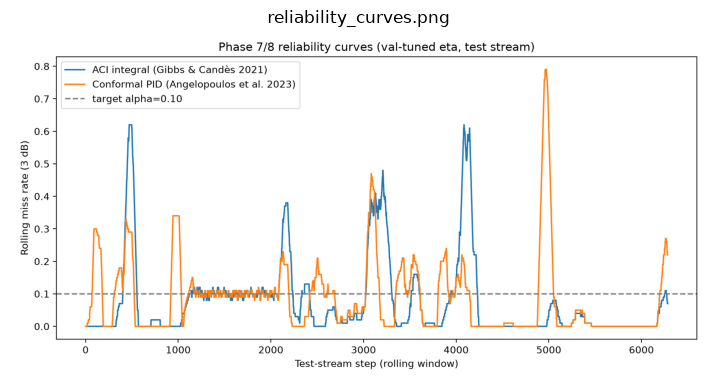

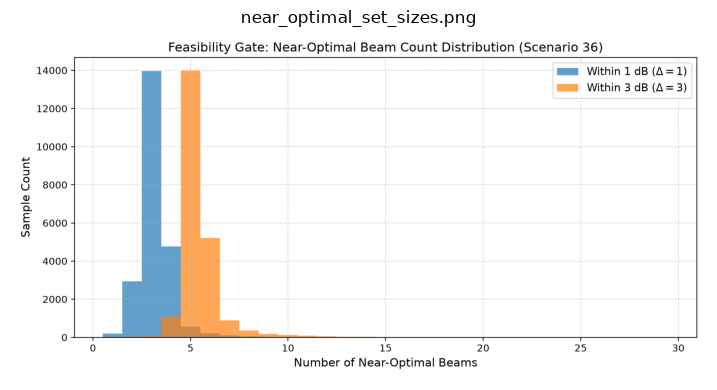

In [6]:
# Reliability curves and near-optimal set sizes
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for fig_path in ['results/reliability_curves.png', 'results/near_optimal_set_sizes.png']:
    p = Path(fig_path)
    if p.exists():
        img = mpimg.imread(str(p))
        plt.figure(figsize=(10, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(p.name)
        plt.tight_layout()
        plt.show()
    else:
        print(f'{fig_path}: MISSING')


In [7]:
# Trivial baselines: majority-class accuracy and mean-profile MAE floor
import json
p = Path('results/eda/trivial_baselines.json')
if p.exists():
    with open(p) as f:
        tb = json.load(f)
    print('Trivial baselines (floor values):')
    for k, v in tb.items():
        print(f'  {k}: {v}')
else:
    print('trivial_baselines.json MISSING')


Trivial baselines (floor values):
  majority_beam: 162
  majority_test_top1: 0.20410401002506265
  mean_profile_test_mae_db: 3.1066043315812006
  phase1_majority_on_raw_frames: 0.16706318803177547


In [8]:
# Multi-delta reliability on Top-5 candidate sets
p = Path('results/eda/topk5_multi_delta_reliability.json')
if p.exists():
    with open(p) as f:
        rel = json.load(f)
    print('Top-5 multi-delta reliability:')
    for k, v in rel.items():
        print(f'  {k}: {v:.4f}')
else:
    print('topk5_multi_delta_reliability.json MISSING')


Top-5 multi-delta reliability:
  miss_rate_delta_0.0db: 0.5321
  coverage_delta_0.0db: 0.4679
  miss_rate_delta_1.0db: 0.2697
  coverage_delta_1.0db: 0.7303
  miss_rate_delta_3.0db: 0.1635
  coverage_delta_3.0db: 0.8365
